# JMA Station Data Exploration

Loads daily station observations from the Japan Meteorological Agency (JMA) for Tokyo, Osaka, and Nagoya, and produces station-level exploratory indices for the 1980-2024 study period. This is pure exploratory work to examine observational point-station counterpart to the ERA5-Land gridded data. Tokyo is the only Kanto station and is the primary subject throughout; Osaka and Nagoya are carried alongside as out-of-region comparison points (the same three stations used for the ERA5-Land vs JMA validation in notebook 03)."


## Setup

Repo-root discovery, `figures/` output directory, decade bins, and station display conventions used throughout this notebook. The final decade bin (2020-2024) is only 5 years wide. Its mean is more sensitive to single outlier years (2024 in particular, see Section 3) than the other bins; flagged again wherever it materially affects a figure's interpretation.

In [1]:
%matplotlib inline

import pathlib
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

_p = pathlib.Path.cwd()
while not (_p / ".git").exists() and _p != _p.parent:
    _p = _p.parent
sys.path.insert(0, str(_p))

from src.jma_data import load_baiu_end_dates, load_stations

NOTEBOOK_ID = "02"
NOTEBOOK_NAME = "02_jma_data_exploration"
FIGURES_DIR = _p / "figures" / NOTEBOOK_NAME
FIGURES_DIR.mkdir(parents=True, exist_ok=True)


def savefig(fig, section: int, fig_num, title: str) -> None:
    """Save *fig* to figures/<notebook>/ using the project convention [NB]_[section]-[fig#]_[title].png."""
    fig.savefig(FIGURES_DIR / f"{NOTEBOOK_ID}_{section}-{fig_num}_{title}.png")


# Decade bins shared with notebook 01. Last bin is 5 years (2020-2024, not 2020-2029).
DECADES = {
    "1980-1989": (1980, 1989),
    "1990-1999": (1990, 1999),
    "2000-2009": (2000, 2009),
    "2010-2019": (2010, 2019),
    "2020-2024": (2020, 2024),
}


def decade_bin(year: int):
    """Map a calendar year to its DECADES label, or None if outside the study period."""
    for label, (start, end) in DECADES.items():
        if start <= year <= end:
            return label
    return None


# Tokyo is the only Kanto station in this set -- Osaka/Nagoya are out-of-region
# comparison points (the same three stations used for the ERA5-Land vs JMA
# validation in notebook 03). Sapporo/Fukuoka are also in data/jma/master_receipt.json
# but are out of scope for this notebook.
STATIONS = ["tokyo", "osaka", "nagoya"]
STATION_LABELS = {"tokyo": "Tokyo", "osaka": "Osaka", "nagoya": "Nagoya"}
STATION_COLORS = {"tokyo": "tab:red", "osaka": "tab:blue", "nagoya": "tab:green"}


def decade_bar_chart(ax, annual_df: pd.DataFrame, value_col: str) -> None:
    """Grouped bar chart of *value_col*, decade means (x) x station (bar group).

    Shared across every decade-comparison figure below so the bar layout,
    spacing, and station colors stay consistent notebook-wide.
    """
    df = annual_df.copy()
    df["decade"] = df["year"].map(decade_bin)
    decade_means = df.groupby(["decade", "station"])[value_col].mean().unstack("station")
    decade_means = decade_means.reindex(index=list(DECADES), columns=STATIONS)

    x = np.arange(len(decade_means.index))
    width = 0.8 / len(STATIONS)
    for i, station in enumerate(STATIONS):
        offset = (i - (len(STATIONS) - 1) / 2) * width
        ax.bar(
            x + offset,
            decade_means[station],
            width=width,
            color=STATION_COLORS[station],
            label=STATION_LABELS[station],
        )
    ax.set_xticks(x)
    ax.set_xticklabels(decade_means.index)

## Data Processing

Every annual station-level index used below is derived here in one place. JMA daily records are small (~16k rows/station, three stations) compared to the ERA5-Land hourly grids in notebook 01, so no on-disk caching is needed. Everything here is a direct pandas `groupby`.

Crude Seasonal windows are set as Baiu = June 1-July 31, heat wave season = July 1-September 30.

In [14]:
daily = load_stations(STATIONS)
daily["year"] = daily["date"].dt.year
daily["month"] = daily["date"].dt.month

heat_season = daily[daily["month"].isin([7, 8, 9])].copy()  # Jul-Sep heat wave season
baiu_season = daily[daily["month"].isin([6, 7])].copy()  # Jun-Jul Baiu season
august = daily[daily["month"] == 8].copy()

# August mean / mean-daily-max temperature, by station and year
annual_aug_mean_temp = august.groupby(["station", "year"])["mean_temp"].mean().reset_index()
annual_aug_max_temp = august.groupby(["station", "year"])["max_temp"].mean().reset_index()

# annual count of >=35C days, Jul-Sep
heat_season["hot_day"] = heat_season["max_temp"] >= 35
annual_hot_days = heat_season.groupby(["station", "year"])["hot_day"].sum().reset_index(name="hot_days")

# annual count of >=25C tropical nights (daily-min temp), Jul-Sep
heat_season["tropical_night"] = heat_season["min_temp"] >= 25
annual_tropical_nights = (
    heat_season.groupby(["station", "year"])["tropical_night"].sum().reset_index(name="tropical_nights")
)

# Jun-Jul mean daily precip and total precip
annual_jj_mean_precip = (
    baiu_season.groupby(["station", "year"])["precipitation"].mean().reset_index(name="mean_daily_precip")
)
annual_jj_total_precip = (
    baiu_season.groupby(["station", "year"])["precipitation"].sum().reset_index(name="total_precip")
)

# heavy-rain-day counts, Jun-Jul, at two candidate thresholds
for threshold in (100, 150):
    baiu_season[f"heavy_rain_{threshold}"] = baiu_season["precipitation"] >= threshold
annual_heavy_rain = (
    baiu_season.groupby(["station", "year"])[["heavy_rain_100", "heavy_rain_150"]].sum().reset_index()
)

# rainy-day counts via the no-phenomenon flag (true-zero vs missing), Jun-Jul
annual_rainy_days = baiu_season.groupby(["station", "year"])["rained"].sum().reset_index(name="rainy_days")

## 1. August Mean Temperature by Station

Daily mean temperature (JMA's `mean_temp` field, the average of 24 hourly readings), restricted to August, averaged within each decade bin. Uses `annual_aug_mean_temp` from Data Processing above.

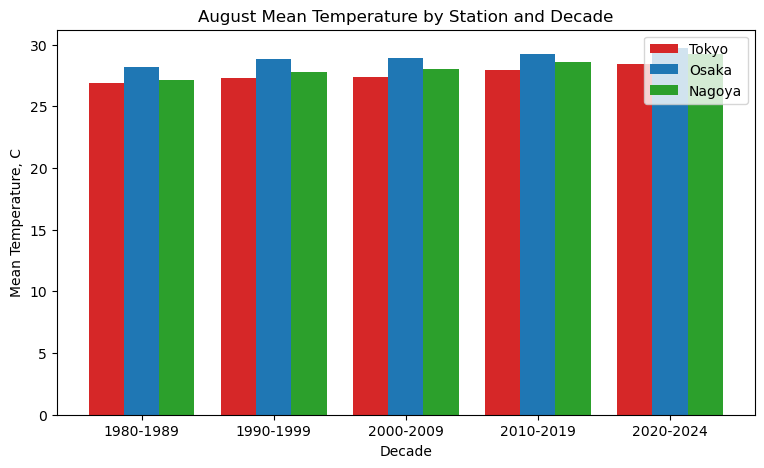

In [3]:
fig, ax = plt.subplots(figsize=(9, 5))
decade_bar_chart(ax, annual_aug_mean_temp, "mean_temp")
ax.set_ylabel("Mean Temperature, C")
ax.set_xlabel("Decade")
ax.set_title("August Mean Temperature by Station and Decade")
ax.legend()
savefig(fig, section=1, fig_num=1, title="jma_aug_mean_temp_by_station")
plt.show()

**Observation:** All three stations warm steadily and fairly uniformly across decades (roughly +1.5 to +2.1 C from 1980-1989 to 2020-2024). Tokyo runs consistently cooler than Osaka and Nagoya in every decade, about 1.3 C below Osaka and 0.3-0.8 C below Nagoya, plausibly reflecting Tokyo's coastal position moderating the daily mean relative to the more inland-influenced Osaka/Nagoya stations. The gap is stable across decades, i.e. Tokyo is not converging with or diverging from the other two.

## 2. August Mean Daily-Max Temperature by Station

Daily maximum temperature, restricted to August, averaged within each decade bin. Uses `annual_aug_max_temp` from Data Processing above. This is the metric most directly comparable to notebook 01's ERA5-Land monthly-max maps and to notebook 03's ERA5-Land vs JMA bias comparison.

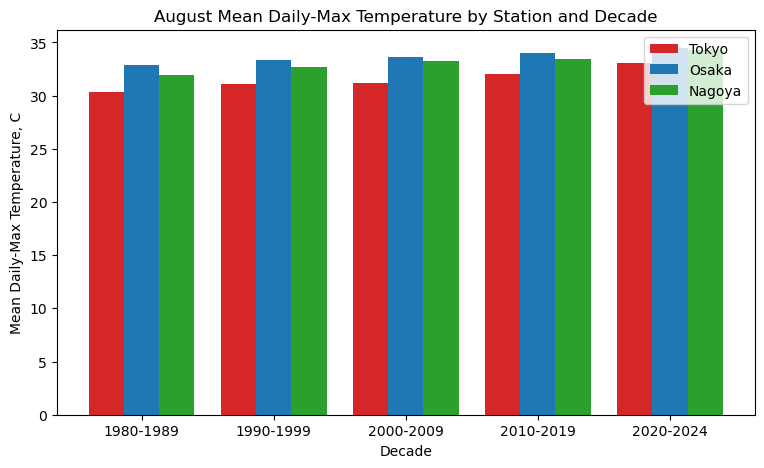

In [4]:
fig, ax = plt.subplots(figsize=(9, 5))
decade_bar_chart(ax, annual_aug_max_temp, "max_temp")
ax.set_ylabel("Mean Daily-Max Temperature, C")
ax.set_xlabel("Decade")
ax.set_title("August Mean Daily-Max Temperature by Station and Decade")
ax.legend()
savefig(fig, section=2, fig_num=1, title="jma_aug_mean_max_temp_by_station")
plt.show()

**Observation:** Same cool-Tokyo pattern as Section 1, but the gap is larger for daily-max than for daily-mean, and it narrows over time: Tokyo trails Osaka by 2.5 C in 1980-1989 but only 1.4 C in 2020-2024, and trails Nagoya by 1.6 C narrowing to 1.2 C. Tokyo's daily-max is warming faster than Osaka/Nagoya's, even though its daily-mean warms at a similar rate to the other two (Section 1), consistent with a shrinking coastal-moderation effect on the hottest part of the day specifically, not a general convergence in climate.

## 3. Annual >=35C Days by Station

Annual count of days with daily-max temperature >=35C, restricted to the Jul-Sep heat wave season. Uses `annual_hot_days` from Data Processing above.

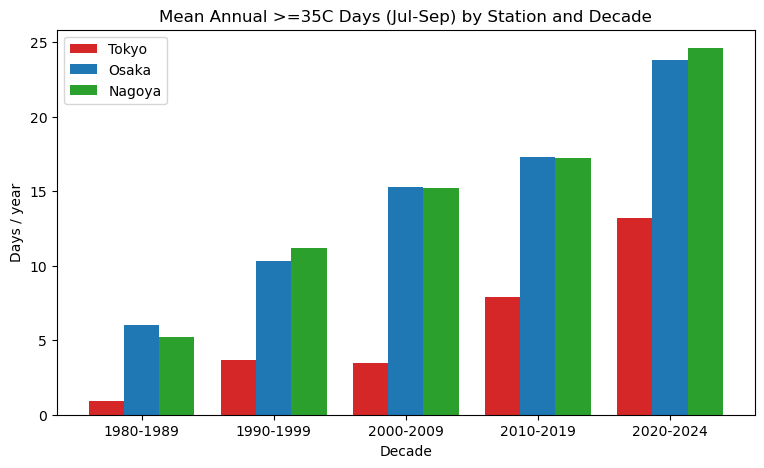

In [5]:
fig, ax = plt.subplots(figsize=(9, 5))
decade_bar_chart(ax, annual_hot_days, "hot_days")
ax.set_ylabel("Days / year")
ax.set_xlabel("Decade")
ax.set_title("Mean Annual >=35C Days (Jul-Sep) by Station and Decade")
ax.legend()
savefig(fig, section=3, fig_num=1, title="jma_annual_hot_days_by_station")
plt.show()

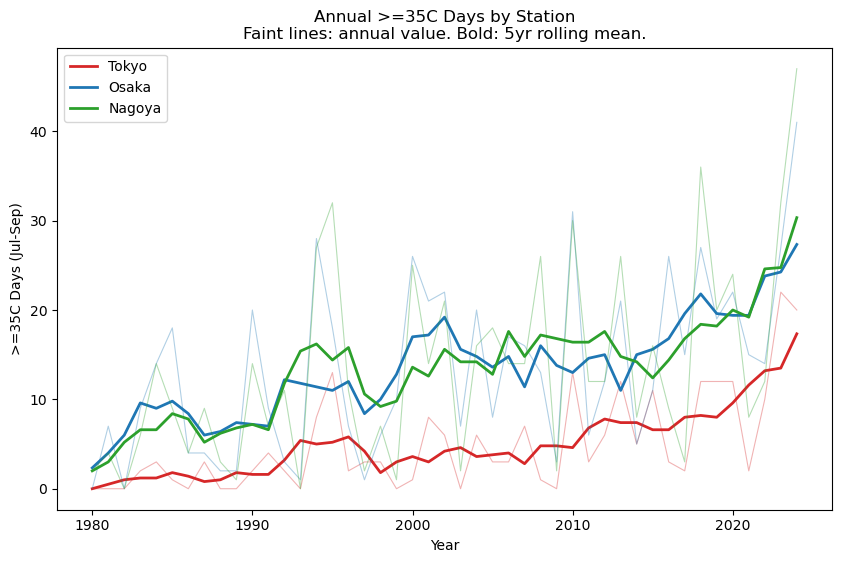

In [6]:
# Annual time series alongside the decade bars: threshold-crossing counts like this are
# noisy year-to-year (a handful of days either side of 35C swings the count a lot), so the
# single-year detail matters here in a way it doesn't for a smooth continuous variable.
fig, ax = plt.subplots(figsize=(10, 6))
for station in STATIONS:
    ts = annual_hot_days[annual_hot_days["station"] == station].sort_values("year")
    ax.plot(ts["year"], ts["hot_days"], color=STATION_COLORS[station], linewidth=0.8, alpha=0.35)
    rolling = ts.set_index("year")["hot_days"].rolling(5, center=True, min_periods=3).mean()
    ax.plot(rolling.index, rolling.values, color=STATION_COLORS[station], linewidth=2, label=STATION_LABELS[station])

ax.set_xlabel("Year")
ax.set_ylabel(">=35C Days (Jul-Sep)")
ax.set_title("Annual >=35C Days by Station\nFaint lines: annual value. Bold: 5yr rolling mean.")
ax.legend()
savefig(fig, section=3, fig_num=2, title="jma_annual_hot_days_timeseries")
plt.show()

**Observation:** A clear, accelerating rise at all three stations. Tokyo goes from under 1 day/year in 1980-1989 to 13.2 in 2020-2024; Osaka and Nagoya from ~5-6 to ~24-25. Tokyo stays consistently lowest across every decade, roughly half of Osaka/Nagoya's count throughout, but the *relative* gap narrows even as the *absolute* gap widens (e.g. 2020-2024: Tokyo 13.2 vs Nagoya 24.6, a ~1.9x ratio, down from a ~5-6x ratio in 1980-1989 when Tokyo's count was near zero).

**On the 2020-2024 bin specifically:** the time series shows why the 5-year-bin caveat matters here: 2024 alone recorded 20 (Tokyo), 41 (Osaka), and 47 (Nagoya) hot days, well above every other year in the record for all three stations. The 2020-2024 decade mean is materially pulled up by this single year; the underlying rolling-mean trend (still clearly upward) is the more defensible read than the bar height alone.

This is also the trustworthy version of notebook 01's Section 3 map, which showed the same rising pattern spatially but at counts suppressed to 0-4 days/year by ERA5-Land's cold bias.

## 4. Annual >=25C Tropical Nights by Station

Annual count of nights with daily-min temperature >=25C, restricted to the same Jul-Sep heat wave season as Section 3's hot-day counts (for like-for-like comparison). Uses `annual_tropical_nights` from Data Processing above, computed the same way as `annual_hot_days`, just against `min_temp` instead of `max_temp`.

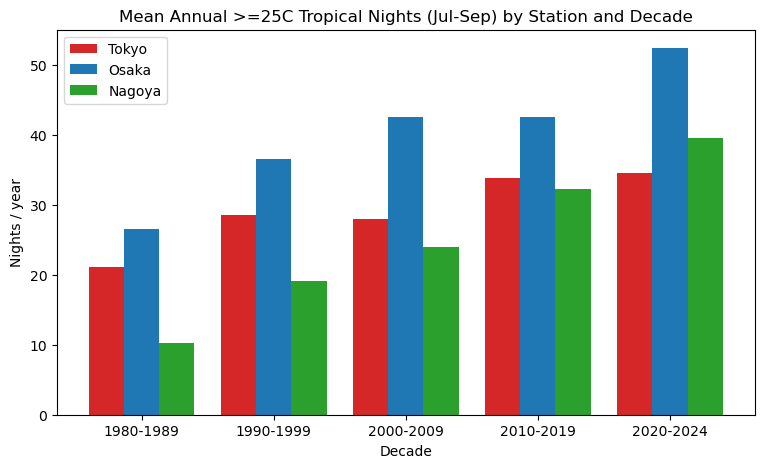

In [7]:
fig, ax = plt.subplots(figsize=(9, 5))
decade_bar_chart(ax, annual_tropical_nights, "tropical_nights")
ax.set_ylabel("Nights / year")
ax.set_xlabel("Decade")
ax.set_title("Mean Annual >=25C Tropical Nights (Jul-Sep) by Station and Decade")
ax.legend()
savefig(fig, section=4, fig_num=1, title="jma_annual_tropical_nights_by_station")
plt.show()

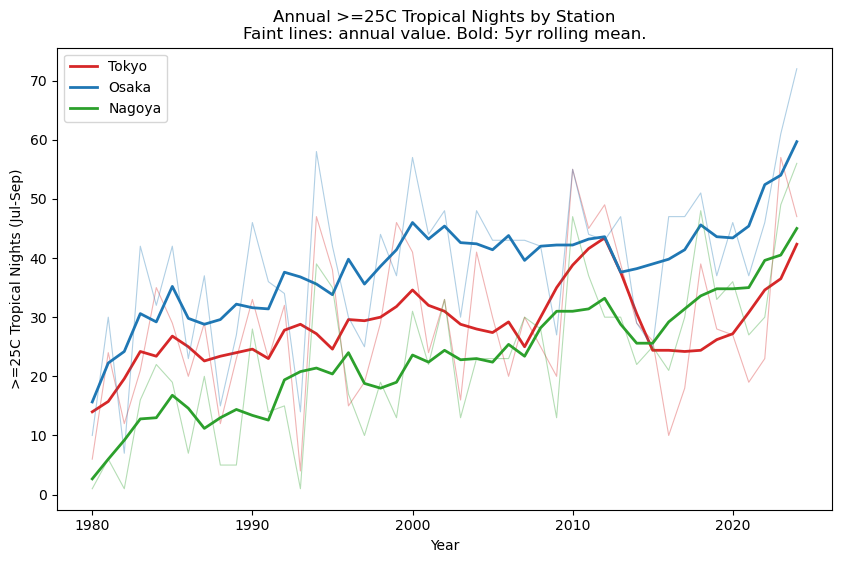

In [8]:
fig, ax = plt.subplots(figsize=(10, 6))
for station in STATIONS:
    ts = annual_tropical_nights[annual_tropical_nights["station"] == station].sort_values("year")
    ax.plot(ts["year"], ts["tropical_nights"], color=STATION_COLORS[station], linewidth=0.8, alpha=0.35)
    rolling = ts.set_index("year")["tropical_nights"].rolling(5, center=True, min_periods=3).mean()
    ax.plot(rolling.index, rolling.values, color=STATION_COLORS[station], linewidth=2, label=STATION_LABELS[station])

ax.set_xlabel("Year")
ax.set_ylabel(">=25C Tropical Nights (Jul-Sep)")
ax.set_title("""Annual >=25C Tropical Nights by Station
Faint lines: annual value. Bold: 5yr rolling mean.""")
ax.legend()
savefig(fig, section=4, fig_num=2, title="jma_annual_tropical_nights_timeseries")
plt.show()

**Observation:** Similar rising trend as the max temperature hot day cuonts in Section 3, with all three stations showing a clear multi-decade increase with far less year-to-year noise. Osaka is the standout: 26.5 nights/year in the 1980s already, climbing to 52.4 by 2020-2024, meaning in recent years a tropical night happens on well over half of all Jul-Sep nights at that station. Nagoya starts lowest (10.2 nights/year in the 1980s) but grows fastest in relative terms (3.9x by 2020-2024, the largest multiplier of the three), overtaking Tokyo by the 2010s. Tokyo grows the least in relative terms (1.6x) despite still nearly doubling in absolute count (21.1 to 34.6).

**2024 vs. Section 3:** 2024 is again a standout year for tropical nights (Osaka 72, Nagoya 56, Tokyo 47; Osaka's 72 means a tropical night on essentially 4 out of every 5 Jul-Sep nights that year), but it is not universally each station's single hottest year on this index. Tokyo's individual peak was actually 2023 (57 nights), not 2024, unlike the hot-day count in Section 3 where 2024 dominated across all three stations. Tropical nights and hot-day counts are related but not identical signals.

Combined with Section 3, this reinforces notebook 01's cross-validation point: ERA5-Land's small Tmin bias means this steadier tropical-night trend is the more directly comparable, trustworthy series against the gridded reanalysis, while the noisier hot-day counts need the bias correction notebook 03 will quantify.

## 5. Baiu-Season (Jun-Jul) Precipitation by Station

Mean daily precipitation and total seasonal precipitation, June 1-July 31 (typical Baiu window), averaged within each decade bin. Uses `annual_jj_mean_precip` and `annual_jj_total_precip` from Data Processing above.

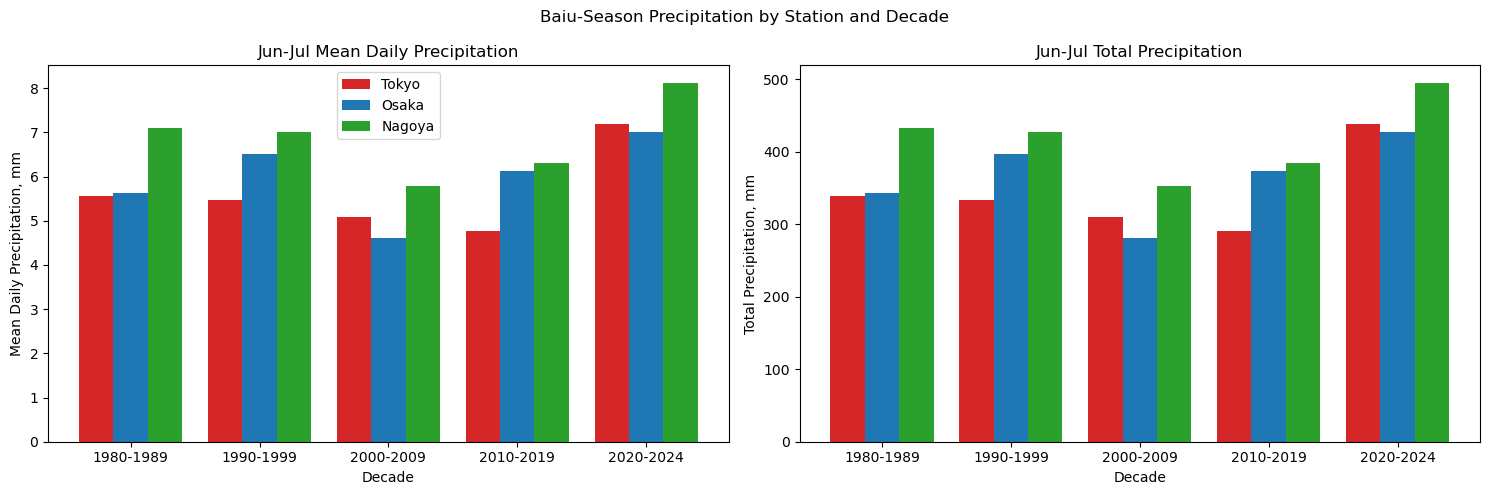

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
decade_bar_chart(axes[0], annual_jj_mean_precip, "mean_daily_precip")
axes[0].set_ylabel("Mean Daily Precipitation, mm")
axes[0].set_xlabel("Decade")
axes[0].set_title("Jun-Jul Mean Daily Precipitation")
axes[0].legend()

decade_bar_chart(axes[1], annual_jj_total_precip, "total_precip")
axes[1].set_ylabel("Total Precipitation, mm")
axes[1].set_xlabel("Decade")
axes[1].set_title("Jun-Jul Total Precipitation")

fig.suptitle("Baiu-Season Precipitation by Station and Decade")
fig.tight_layout()
savefig(fig, section=5, fig_num=1, title="jma_jj_precip_by_station")
plt.show()

**Observation:** No clean monotonic trend at any station. All three dip in 2000-2009 relative to both the preceding and following decades (e.g. Tokyo total: 338.5mm in 1980-1989, down to 310.8mm in 2000-2009, then up to 438.4mm by 2020-2024). The 2020-2024 bin is the wettest at all three stations, but per the 5-year-bin caveat this could again be dominated by a small number of extreme years rather than a settled new regime. Point-station totals are also visibly noisy (mean-daily and total don't always move together, e.g. Tokyo 1990-1999 mean-daily is lower than 1980-1989's despite total being close).

## 6. Heavy-Rain-Day Counts (>=100mm / >=150mm) - a Negative Result

Annual count of Jun-Jul days exceeding 100mm and 150mm of daily precipitation, averaged within each decade bin. Uses `annual_heavy_rain` from Data Processing above.

Included deliberately as a **documented negative result**, not because the figure below shows a usable signal: at a single point station, days this extreme are rare enough that decade means are dominated by whether zero, one, or two events happened to fall in that window, not by any underlying climatological rate.

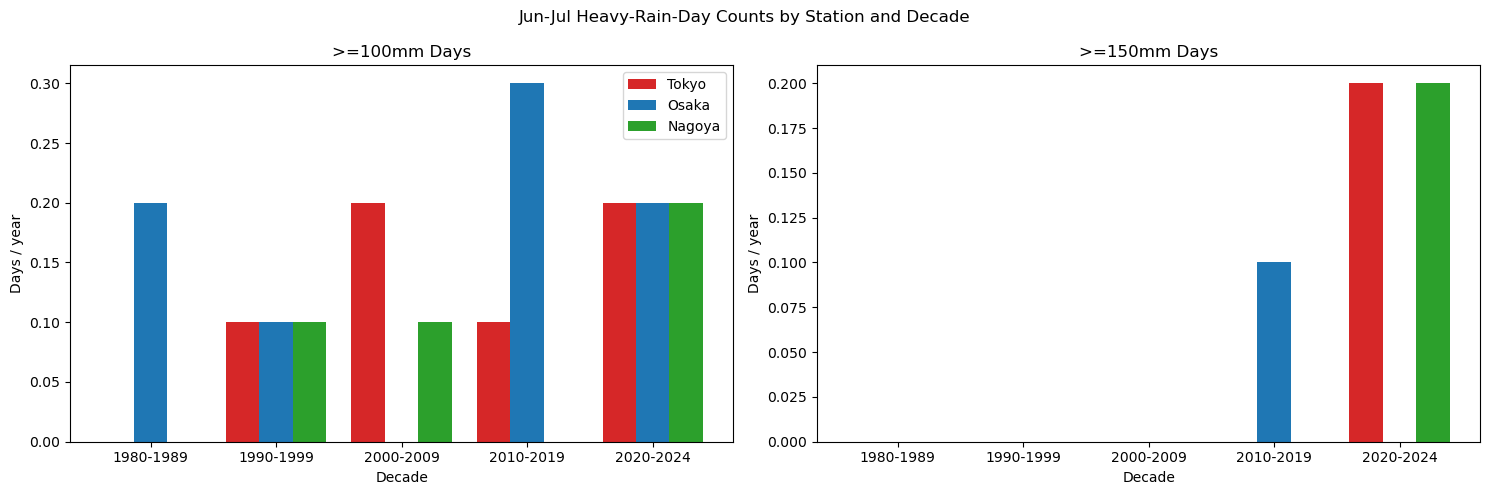

Total >=100mm days, full 1980-2024 record, by station:
station
nagoya    3
osaka     7
tokyo     5
Name: heavy_rain_100, dtype: int64


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
decade_bar_chart(axes[0], annual_heavy_rain, "heavy_rain_100")
axes[0].set_ylabel("Days / year")
axes[0].set_xlabel("Decade")
axes[0].set_title(">=100mm Days")
axes[0].legend()

decade_bar_chart(axes[1], annual_heavy_rain, "heavy_rain_150")
axes[1].set_ylabel("Days / year")
axes[1].set_xlabel("Decade")
axes[1].set_title(">=150mm Days")

fig.suptitle("Jun-Jul Heavy-Rain-Day Counts by Station and Decade")
fig.tight_layout()
savefig(fig, section=6, fig_num=1, title="jma_heavy_rain_days_by_station")
plt.show()

print("Total >=100mm days, full 1980-2024 record, by station:")
print(annual_heavy_rain.groupby("station")["heavy_rain_100"].sum())

**Observation (negative result):** Over the full 45-year record, each station sees only 3-7 total Jun-Jul days >=100mm (Tokyo 5, Osaka 7, Nagoya 3), and >=150mm days are essentially absent. Only a handful of individual station-decades register even a single such event. Decade means sit at 0.0-0.3 days/year throughout, with no interpretable pattern across decades: a bar of 0.2 days/year can mean "one event happened to fall in these 10 years" as easily as it can mean "two." This is too sparse a sample at point-station scale to support any trend claim, positive or negative, about heavy-rain-day frequency. It reinforces the same conclusion as Section 5's total/mean-daily precip: extreme-tail precipitation intensity needs either a spatial approach (ERA5-Land's gridded R95p, notebook 01 Section 5) or a much larger station network than the three used here.

## 7. Rainy-Day Counts by Station

Annual count of Jun-Jul days on which precipitation occurred, using the `rained` field from `src.jma_data.load_station` (derived from the no-phenomenon flag, so a reported 0.0mm on a day the flag marks as "occurred", e.g. trace rain rounding to zero, is correctly counted as a rainy day, not silently dropped). Uses `annual_rainy_days` from Data Processing above.

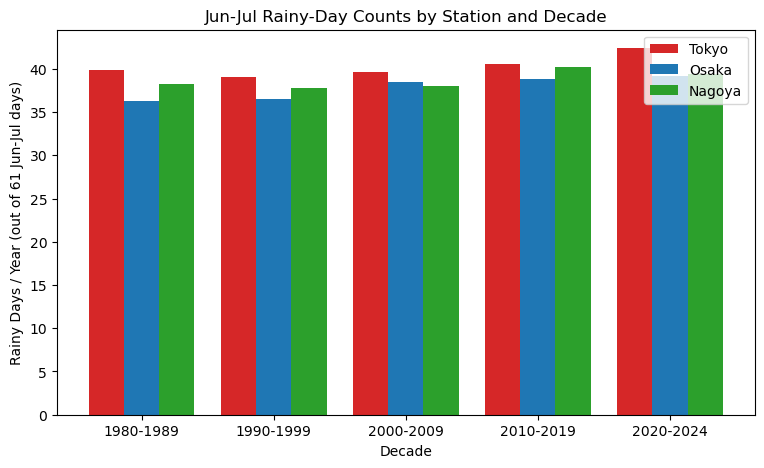

In [11]:
fig, ax = plt.subplots(figsize=(9, 5))
decade_bar_chart(ax, annual_rainy_days, "rainy_days")
ax.set_ylabel("Rainy Days / Year (out of 61 Jun-Jul days)")
ax.set_xlabel("Decade")
ax.set_title("Jun-Jul Rainy-Day Counts by Station and Decade")
ax.legend()
savefig(fig, section=7, fig_num=1, title="jma_rainy_days_by_station")
plt.show()

**Observation:** All three stations cluster tightly in a 36-42 day/year band (out of 61 possible Jun-Jul days) with only a mild upward drift across decades, not the kind of separation seen in the temperature indices above. Tokyo is marginally the wettest-by-day-count station in most decades, which sits somewhat in tension with Section 5 (where Nagoya has the highest total/mean precipitation), consistent with a station receiving *more frequent but lighter* rain rather than *heavier* rain, though disentangling that needs the intensity-per-rain-day view, not day-counts alone.

## 8. JMA Official Baiu Onset/Withdrawal Dates (Kanto-Koshin)

Unlike Sections 1-6, this section uses a different JMA source: the agency's own official annual Baiu (rainy season) onset and withdrawal declarations for the Kanto-Koshin region, not derived from the station daily records above. Loaded via `src.jma_data.load_baiu_end_dates()` (`data/jma/baiu_end_dates_1980_2025.csv`); see `data/jma/baiu_data_readme.md` for full provenance.

These are the reference dates any potential Baiu-detection algorithm applied to ERA5-Land precipitation (notebook 01) will eventually be validated against for RQ2, and the source of the Baiu withdrawal date used in the RQ3 coupling hypothesis.

**Data caveats:**
- All JMA dates carry an implicit "approximately" (頃) qualifier. The Baiu transition is a ~5-day gradual process, not a discrete event, though dates are recorded here as the exact day JMA cites.
- **1993 has no withdrawal declaration**. That season transitioned directly into an abnormally cool, wet summer without a clear precipitation break. `baiu_end_date` and the derived `season_length_days` are missing for this year and excluded from any withdrawal-date or season-length statistic below.

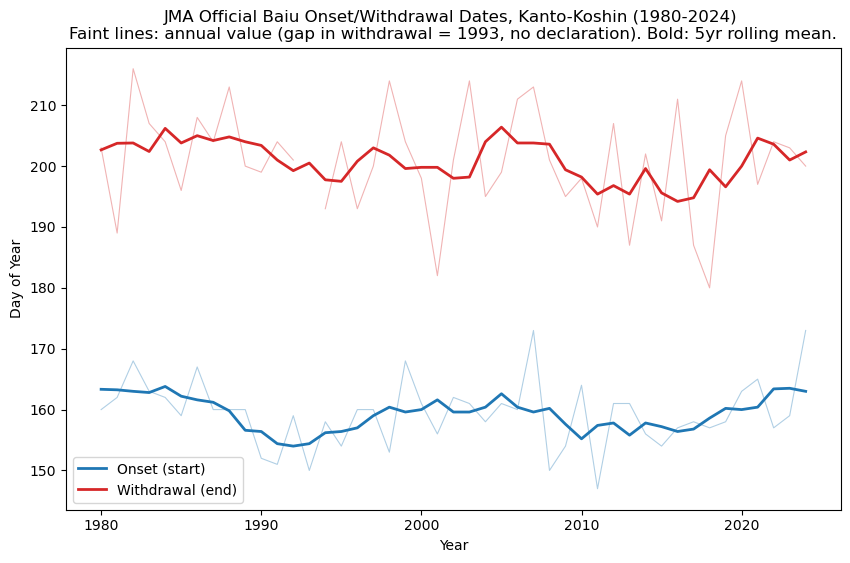

In [12]:
baiu = load_baiu_end_dates()
baiu["start_doy"] = baiu["baiu_start_date"].dt.dayofyear
baiu["end_doy"] = baiu["baiu_end_date"].dt.dayofyear
baiu["decade"] = baiu["year"].map(decade_bin)
baiu_study = baiu[baiu["year"] <= 2024]  # exclude 2025 -- beyond the committed 1980-2024 study period

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(baiu_study["year"], baiu_study["start_doy"], color="tab:blue", linewidth=0.8, alpha=0.35)
start_rolling = baiu_study.set_index("year")["start_doy"].rolling(5, center=True, min_periods=3).mean()
ax.plot(start_rolling.index, start_rolling.values, color="tab:blue", linewidth=2, label="Onset (start)")

ax.plot(baiu_study["year"], baiu_study["end_doy"], color="tab:red", linewidth=0.8, alpha=0.35)
end_rolling = baiu_study.set_index("year")["end_doy"].rolling(5, center=True, min_periods=3).mean()
ax.plot(end_rolling.index, end_rolling.values, color="tab:red", linewidth=2, label="Withdrawal (end)")

ax.set_xlabel("Year")
ax.set_ylabel("Day of Year")
ax.set_title(
    "JMA Official Baiu Onset/Withdrawal Dates, Kanto-Koshin (1980-2024) \n"
    "Faint lines: annual value (gap in withdrawal = 1993, no declaration). Bold: 5yr rolling mean."
)
ax.legend()
savefig(fig, section=8, fig_num=1, title="jma_baiu_onset_withdrawal_timeseries")
plt.show()

**Observation:** Onset date shows no directional trend. It wobbles by about a week decade-to-decade (mean day-of-year ranges from Jun 5 in the 1990s to Jun 12 in 2020-2024) with no consistent drift earlier or later across 45 years. Withdrawal is where the shape is: the rolling mean drifts *earlier* through the 1990s-2010s before swinging back later by the early 2020s, non-monotonic, not a simple linear shift in either direction. The 1993 gap sits in the record as a genuine missing declaration, not a data error. 2024 stands out with one of the latest onsets on record (Jun 21, tied with 2007 for latest in the whole series) paired with a below-average season length (27 days), consistent with the unusually late-starting but intense Baiu already flagged from the ERA5-Land side in notebook 01.

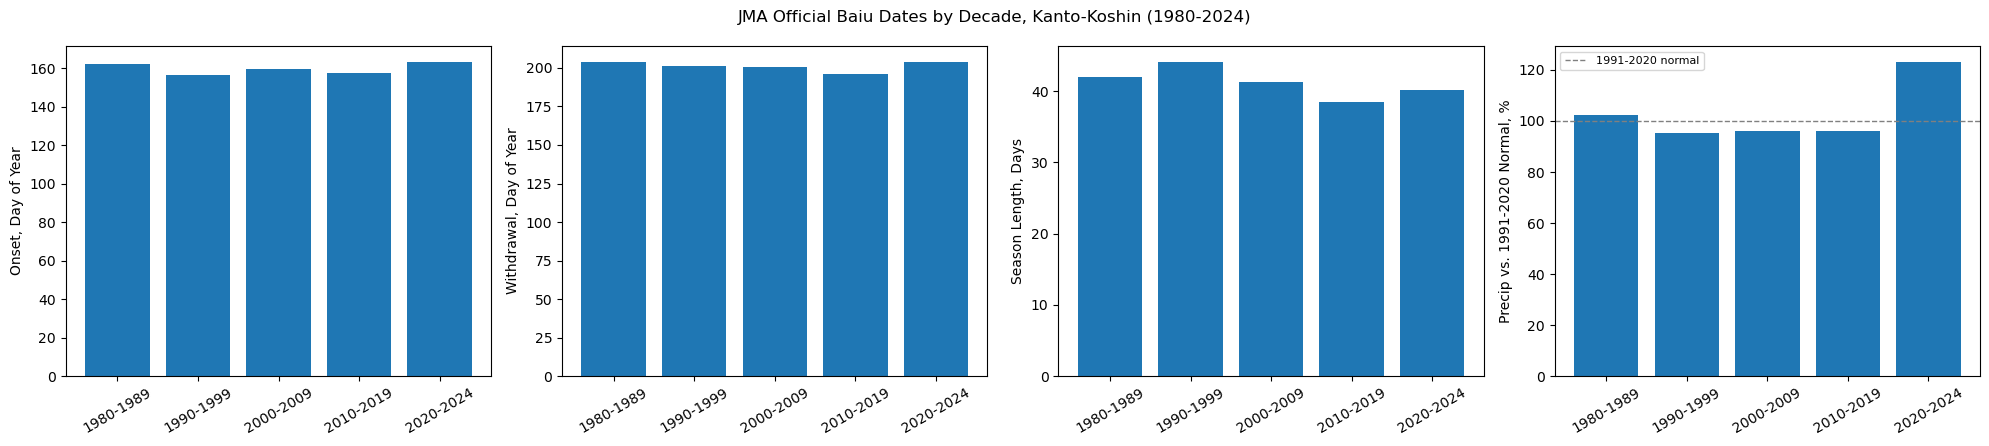

In [13]:
decade_stats = (
    baiu_study.groupby("decade")[["start_doy", "end_doy", "season_length_days", "precip_ratio"]]
    .mean()
    .reindex(list(DECADES))
)

fig, axes = plt.subplots(1, 4, figsize=(20, 4.5))
panels = [
    ("start_doy", "Onset, Day of Year"),
    ("end_doy", "Withdrawal, Day of Year"),
    ("season_length_days", "Season Length, Days"),
    ("precip_ratio", "Precip vs. 1991-2020 Normal, %"),
]
for ax, (col, ylabel) in zip(axes, panels):
    ax.bar(decade_stats.index, decade_stats[col], color="tab:blue")
    ax.set_ylabel(ylabel)
    ax.tick_params(axis="x", rotation=30)
    if col == "precip_ratio":
        ax.axhline(100, color="gray", linestyle="--", linewidth=1, label="1991-2020 normal")
        ax.legend(fontsize=8)

fig.suptitle("JMA Official Baiu Dates by Decade, Kanto-Koshin (1980-2024)")
fig.tight_layout()
savefig(fig, section=8, fig_num=2, title="jma_baiu_decade_summary")
plt.show()

**Observation:** Withdrawal moves from Jul 23 (1980s) to Jul 19 (2000s) to Jul 14 (2010s). Three decades of real earlier-withdrawal drift, before swinging back to Jul 22 in 2020-2024, while onset stays within a Jun 5-12 band throughout with no equivalent monotonic stretch. Though at this scale its hard to say whether this can be considered a persistent trend.

**The precipitation-ratio panel is the standout finding here.** It sits flat at 95-96% of the 1991-2020 normal for three straight decades (1990s, 2000s, 2010s) before jumping to 123% in 2020-2024. This corroborates the R95p precipitation intensification notebook 01 Section 5 found over the same 2020-2024 window from the gridded reanalysis side. Two independent data sources agreeing on a recent Baiu-intensity jump is a stronger basis for the RQ2 narrative than either alone, though, per the 5-year-bin caveat that applies throughout this project, both could still be reflecting the same handful of outlier years (2020 and 2024 in particular) rather than a settled new regime.

**Notable years for the record:** 1993 (no withdrawal declared, 144% precip, the anomalously wet, cool exception), 2024 (tied-latest onset on record, 113% precip), and 2025 (earliest onset in the entire 46-year record at May 22, well outside this notebook's study period but worth flagging for whoever extends the analysis past 2024).

## Key Findings

- **Temperature indices carry the clear, usable signal.** August mean and mean-daily-max temperature, and annual >=35C hot-day counts, all show steady-to-accelerating warming at Tokyo, Osaka, and Nagoya across 1980-2024. Tokyo runs consistently cooler than Osaka/Nagoya (coastal moderation), and this offset is stable for daily-mean but narrowing for daily-max.
- **Tropical-night counts** All three stations show a clear multi-decade rise: Osaka leads throughout (26.5 to 52.4 nights/yr, 1980s to 2020-2024, over half the season's nights by the recent decade), Nagoya grows fastest in relative terms (3.9x), Tokyo grows least (1.6x) but still nearly doubles. Because ERA5-Land's cold bias against Tmin/tropical-nights is small (unlike its Tmax/hot-day bias), this is the more directly trustworthy series for cross-validation against the gridded reanalysis in notebook 03.
- **Precipitation indices at point-station scale are noisy and largely uninformative for trend detection.** Jun-Jul mean/total precipitation is non-monotonic (a 2000s dip at all three stations); heavy-rain-day counts (>=100/150mm) are too sparse (3-7 events per station across 45 years) to support any trend claim; rainy-day counts cluster tightly across stations with only mild drift. None of these motivate a station-based approach to RQ2. They motivate the opposite: ERA5-Land's spatial averaging and R95p intensity-tail treatment (notebook 01 Section 5) is where the Baiu signal is actually visible.
- **This notebook's hot-day counts are the validation target for notebook 01's cold-bias caveat.** ERA5-Land undercounts >=35C days severely (0-4/year even by 2020-2024) against these station counts (13-25/year in the same period).. Notebook 03 will quantify that bias directly, station by station.

- **JMA's own official Baiu dates (Section 8) independently corroborate the ERA5-Land precipitation-intensification finding.** Withdrawal drifted genuinely earlier from the 1980s through the 2010s before swinging back later in 2020-2024; the precipitation-ratio-vs-normal metric jumped from a flat ~95-96% (1990s-2010s) to 123% in 2020-2024. This matches notebook 01's R95p signal from a completely independent measurement. Onset date itself shows no trend. 1993's missing withdrawal declaration and 2025's record-earliest onset (outside the study period) are both flagged as genuine data points, not errors.